# Model Explainability using SHAP

In [1]:
import pandas as pd
import shap
import joblib
import matplotlib.pyplot as plt

# We'll use XGBoost as the explainer model since SHAP TreeExplainer supports it well,
# or we can use the XGBoost component of our Stacking model.
X_train = pd.read_csv('../data/X_train_scaled.csv')
X_test = pd.read_csv('../data/X_test_scaled.csv')

# Load the stacking model
stack_model = joblib.load('../models/stacking.pkl')

# Extract the XGBoost model from the stacking estimators
xgb_model = stack_model.named_estimators_['xgb']

# Initialize SHAP explainer
explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test)


## Summary Plot

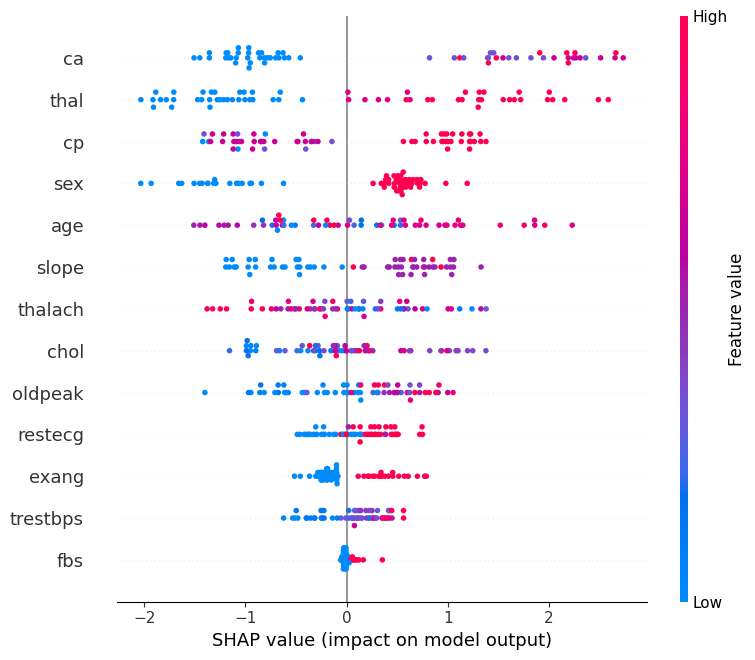

In [2]:
plt.figure()
shap.summary_plot(shap_values, X_test, show=False)
plt.savefig('../images/shap_summary.png', bbox_inches='tight')
plt.show()


## Waterfall Plot (Local Explanation)

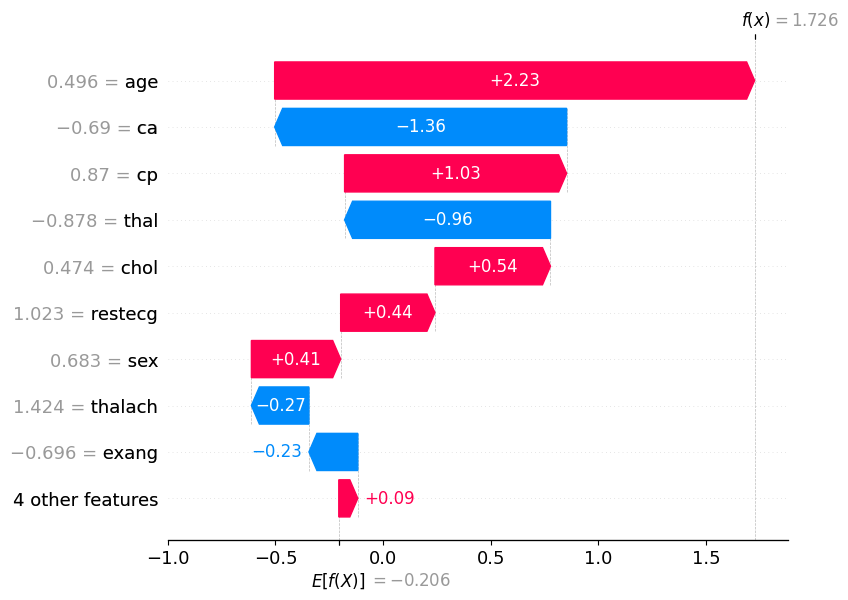

In [3]:
# For the first patient in the test set
idx = 0
plt.figure()
# shap.plots.waterfall is preferred for modern SHAP, requires Explanation object
explainer_v2 = shap.Explainer(xgb_model)
shap_values_v2 = explainer_v2(X_test)

shap.plots.waterfall(shap_values_v2[idx], show=False)
plt.savefig('../images/shap_waterfall.png', bbox_inches='tight')
plt.show()
